<a href="https://colab.research.google.com/github/Shashank-sketchAl/ML-90-Day-Challenge-/blob/main/Day_12_%E2%80%94_Support_Vector_Machine_(SVM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SVM — Key Idea

Support Vector Machine finds a decision boundary
that separates classes while maximizing the margin
between them.

The training points closest to the decision boundary
are called support vectors.

SVM can be used for:
- Classification
- Regression
- Non-linear classification using kernels



In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(data.target)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget names:")
print(data.target_names)

X shape: (569, 30)
y shape: (569,)

Target names:
['malignant' 'benign']


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42,stratify=y)

print("Training samples:",X_train.shape[0])
print("Testing samples:",X_test.shape[0])

Training samples: 455
Testing samples: 114


In [5]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

print("First 5 scaled rows:")
print(X_train_scaled[:5])

First 5 scaled rows:
[[-1.07200079e+00 -6.58424598e-01 -1.08808010e+00 -9.39273639e-01
  -1.35939882e-01 -1.00871795e+00 -9.68358632e-01 -1.10203235e+00
   2.81062120e-01 -1.13231479e-01 -7.04860874e-01 -4.40938351e-01
  -7.43948977e-01 -6.29804931e-01  7.48061001e-04 -9.91572979e-01
  -6.93759567e-01 -9.83284458e-01 -5.91579010e-01 -4.28972052e-01
  -1.03409427e+00 -6.23497432e-01 -1.07077336e+00 -8.76534437e-01
  -1.69982346e-01 -1.03883630e+00 -1.07899452e+00 -1.35052668e+00
  -3.52658049e-01 -5.41380026e-01]
 [ 1.74874285e+00  6.65017334e-02  1.75115682e+00  1.74555856e+00
   1.27446827e+00  8.42288215e-01  1.51985232e+00  1.99466430e+00
  -2.93045055e-01 -3.20179716e-01  1.27567198e-01 -3.81382677e-01
   9.40746962e-02  3.17524379e-01  6.39656015e-01  8.73892616e-02
   7.08450758e-01  1.18215034e+00  4.26212305e-01  7.47970186e-02
   1.22834212e+00 -9.28334970e-02  1.18746742e+00  1.10438613e+00
   1.51700092e+00  2.49654896e-01  1.17859444e+00  1.54991557e+00
   1.91077868e-01 -1

In [6]:
from sklearn.svm import SVC
svm_model = SVC(kernel='linear',C=1)

svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)
print("Prediction:")
print(y_pred[:10])

Prediction:
[0 1 0 0 0 1 1 0 0 0]


In [9]:
from sklearn.metrics import(accuracy_score, precision_score,recall_score,f1_score,roc_auc_score)

accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9736842105263158
Precision: 0.9859154929577465
Recall   : 0.9722222222222222
F1 Score : 0.9790209790209791


In [10]:
print("Number of support vectors:", len(svm_model.support_))

print("\nSupport vectors per class:")
print(svm_model.n_support_)

Number of support vectors: 32

Support vectors per class:
[15 17]


Support Vectors:
Support vectors are training samples closest to the
decision boundary. They are critical in determining
the position of the SVM decision boundary.

`support_` → indices of support vectors
`n_support_` → number of support vectors for each class

In [11]:
C_values = [0.01, 0.1, 1, 10, 100]

for c in C_values:
  model = SVC(kernel='linear', C=c)
  model.fit(X_train_scaled, y_train)
  pred = model.predict(X_test_scaled)
  accuracy = accuracy_score(y_test, y_pred)

  f1=f1_score(y_test,pred)
  print(f"C = {c}")
  print(f"Accuracy = {accuracy:.4f}")
  print(f"F1 Score = {f1:.4f}")
  print("-" * 30)


C = 0.01
Accuracy = 0.9737
F1 Score = 0.9726
------------------------------
C = 0.1
Accuracy = 0.9737
F1 Score = 0.9861
------------------------------
C = 1
Accuracy = 0.9737
F1 Score = 0.9790
------------------------------
C = 10
Accuracy = 0.9737
F1 Score = 0.9861
------------------------------
C = 100
Accuracy = 0.9737
F1 Score = 0.9793
------------------------------


In [12]:
svm_rbf = SVC(
    kernel='rbf',
    C=1
)

svm_rbf.fit(X_train_scaled, y_train)

rbf_pred = svm_rbf.predict(X_test_scaled)

rbf_accuracy = accuracy_score(y_test, rbf_pred)
rbf_precision = precision_score(y_test, rbf_pred)
rbf_recall = recall_score(y_test, rbf_pred)
rbf_f1 = f1_score(y_test, rbf_pred)

print("RBF SVM Results")
print("Accuracy :", rbf_accuracy)
print("Precision:", rbf_precision)
print("Recall   :", rbf_recall)
print("F1 Score :", rbf_f1)


RBF SVM Results
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112


In [13]:
gamma_values = ['scale', 0.001, 0.01, 0.1, 1]

for gamma in gamma_values:

    model = SVC(
        kernel='rbf',
        C=1,
        gamma=gamma
    )

    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print(f"Gamma = {gamma}")
    print(f"Accuracy = {accuracy:.4f}")
    print(f"F1 Score = {f1:.4f}")
    print("-" * 30)

Gamma = scale
Accuracy = 0.9825
F1 Score = 0.9861
------------------------------
Gamma = 0.001
Accuracy = 0.9561
F1 Score = 0.9664
------------------------------
Gamma = 0.01
Accuracy = 0.9825
F1 Score = 0.9861
------------------------------
Gamma = 0.1
Accuracy = 0.9561
F1 Score = 0.9645
------------------------------
Gamma = 1
Accuracy = 0.6316
F1 Score = 0.7742
------------------------------


In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

C_values = [0.1, 1, 10]
gamma_values = ['scale', 0.01, 0.1]

results = []

for c in C_values:
    for gamma in gamma_values:

        model = SVC(
            kernel='rbf',
            C=c,
            gamma=gamma
        )

        scores = cross_val_score(
            model,
            X_train_scaled,
            y_train,
            cv=cv,
            scoring='accuracy'
        )

        results.append({
            'C': c,
            'Gamma': gamma,
            'Mean CV Accuracy': scores.mean(),
            'Std': scores.std()
        })

results_df = pd.DataFrame(results)

print(results_df)

      C  Gamma  Mean CV Accuracy       Std
0   0.1  scale          0.945055  0.013900
1   0.1   0.01          0.947253  0.012815
2   0.1    0.1          0.938462  0.014906
3   1.0  scale          0.967033  0.015541
4   1.0   0.01          0.971429  0.014906
5   1.0    0.1          0.956044  0.012038
6  10.0  scale          0.969231  0.012815
7  10.0   0.01          0.975824  0.016150
8  10.0    0.1          0.945055  0.023051


SVM Hyperparameter Selection

Hyperparameters such as C and gamma should ideally
be selected using cross-validation on the training data.

The test set should be kept separate and used for
final unbiased evaluation.

Workflow:
1. Split data into train/test
2. Use CV on training data
3. Select hyperparameters
4. Train final model using selected parameters
5. Evaluate on test set

In [15]:
best_row = results_df.loc[
    results_df['Mean CV Accuracy'].idxmax()
]

best_C = best_row['C']
best_gamma = best_row['Gamma']

print("Best C:", best_C)
print("Best Gamma:", best_gamma)
print("Best CV Accuracy:", best_row['Mean CV Accuracy'])

Best C: 10.0
Best Gamma: 0.01
Best CV Accuracy: 0.9758241758241759


In [16]:
final_svm = SVC(
    kernel='rbf',
    C=best_C,
    gamma=best_gamma
)

final_svm.fit(X_train_scaled, y_train)

final_pred = final_svm.predict(X_test_scaled)

In [17]:
final_accuracy = accuracy_score(y_test, final_pred)
final_precision = precision_score(y_test, final_pred)
final_recall = recall_score(y_test, final_pred)
final_f1 = f1_score(y_test, final_pred)

print("Final SVM Results")
print("-------------------------")
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1 Score : {final_f1:.4f}")

Final SVM Results
-------------------------
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1 Score : 0.9861


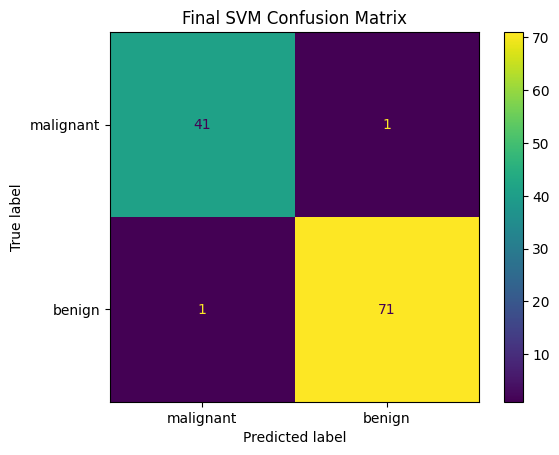

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred,
    display_labels=data.target_names
)

plt.title("Final SVM Confusion Matrix")
plt.show()

In [19]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    final_pred,
    target_names=data.target_names
))

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



DAY 12 — SUPPORT VECTOR MACHINE

SVM finds a decision boundary that separates classes
while maximizing the margin.

Support vectors:
Training samples closest to the decision boundary.

C:
Controls the penalty for classification errors.

Small C:
- More tolerance for errors
- Wider margin
- Stronger regularization

Large C:
- Less tolerance for errors
- Narrower margin
- Can potentially overfit

Kernel:
Allows SVM to model relationships beyond a simple
linear boundary.

Common kernels:
- linear
- rbf
- polynomial
- sigmoid

RBF:
Radial Basis Function kernel.
Useful for non-linear relationships.

Gamma:
Controls the influence/range of individual samples.

Low gamma:
- Broader influence
- Smoother boundary

High gamma:
- More local influence
- More complex boundary
- Can overfit

Important:
Scale features before using SVM.

Hyperparameter selection:
Use cross-validation on training data.

Final evaluation:
Use the test set only after model/hyperparameter
selection.